In [1]:
import os
import re
import torch
import gc
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from nnsight import VisionLanguageModel

import warnings
warnings.filterwarnings("ignore")

load_dotenv()
hf_token = os.getenv('HF_TOKEN')

/home/ubuntu/told-vs-inferred/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import nnsight, transformers
print(f"torch version: {torch.__version__}")
print(f"transformers version: {transformers.__version__}")
print(f"nnsight version: {nnsight.__version__}")

torch version: 2.12.0+cu130
transformers version: 5.9.0
nnsight version: 0.7.0


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [4]:
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU Memory | free: {free/1e9:.1f} GB / total: {total/1e9:.1f} GB (used: {(total-free)/1e9:.1f} GB)")

clear_memory()

GPU Memory | free: 23.4 GB / total: 23.7 GB (used: 0.2 GB)


In [5]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

MODEL_ID = "google/gemma-4-E2B-it"
model = VisionLanguageModel(MODEL_ID, device_map=DEVICE, dtype=torch.float16, dispatch=True)
tokenizer = model.tokenizer

cfg = getattr(model.config, "text_config", model.config)
N_LAYERS = cfg.num_hidden_layers
D = cfg.hidden_size
print(f"layers={N_LAYERS}, hidden={D}")

Loading weights: 100%|██████████| 1951/1951 [00:01<00:00, 1325.95it/s]


layers=35, hidden=1536


In [6]:
with model.trace("Hello world! This is a test."):
    h = model.model.language_model.layers[0].input.save()
print("residual vector shape,", h.shape) 

residual vector shape, torch.Size([1, 8, 1536])


In [7]:
DATA_ROOT = Path('/home/ubuntu/told-vs-inferred')
data_dirs = [
    DATA_ROOT / 'data' / 'llama_gender_1',
    DATA_ROOT / 'data' / 'llama_gender_2',
    DATA_ROOT / 'data' / 'llama_gender_3'
]

In [8]:
ROLE_MAP = {"HUMAN": "user", "ASSISTANT": "assistant"}

def parse_conversation(text):
    turns = []
    pattern = r'(HUMAN|ASSISTANT):\s*(.*?)(?=(?:HUMAN|ASSISTANT):|$)'
    matches = re.findall(pattern, text, re.DOTALL)
    for speaker, content in matches:
        turns.append({'role': ROLE_MAP[speaker], 'content': content.strip()})
    return turns

def apply_chat_template(turns):
    return tokenizer.apply_chat_template(turns, tokenize=False, add_generation_prompt=False)

conversations = {}
gender_labels = {}

for data_dir in data_dirs:
    if not data_dir.exists():
        print(f"skipping {data_dir} (not found)")
        continue
    
    for file in sorted(data_dir.glob("*.txt")):
        parts = re.split(r'_(?:gender|age)_', file.stem)
        conv_id = int(re.search(r'\d+', parts[0]).group())
        gender = parts[1]
        key = (conv_id, gender)
        
        with open(file, 'r') as f:
            raw_text = f.read()
        
        turns = parse_conversation(raw_text)
        full_text = apply_chat_template(turns)
        
        conversations[key] = {
            'turns': turns,
            'full_text': full_text,
            'raw': raw_text,
            'file': file.name
        }
        gender_labels[key] = gender

by_gender = {'male': {}, 'female': {}}
for key, gender in gender_labels.items():
    by_gender[gender][key] = conversations[key]

print(f"loaded {len(conversations)} conversations")
print(f"male: {len(by_gender['male'])}, female: {len(by_gender['female'])}")
print("\nsample formatted conversation:\n")
print(conversations[list(conversations.keys())[0]]['full_text'][:500])

loaded 1000 conversations
male: 500, female: 500

sample formatted conversation:

<bos><|turn>user
Hi! I'm looking for a good restaurant in the city. Do you have any recommendations?<turn|>
<|turn>model
Of course! There are so many great restaurants in the city. What kind of cuisine are you in the mood for?<turn|>
<|turn>user
Hmm, I'm not sure. Something with a lot of veggies and lean protein, but not too heavy. Maybe something Mediterranean?<turn|>
<|turn>model
Great choice! There's a new Greek restaurant in the city that's getting amazing reviews. They have a variety of dis


In [9]:
model.model

Gemma4Model(
  (vision_tower): Gemma4VisionModel(
    (patch_embedder): Gemma4VisionPatchEmbedder(
      (input_proj): Linear(in_features=768, out_features=768, bias=False)
    )
    (encoder): Gemma4VisionEncoder(
      (rotary_emb): Gemma4VisionRotaryEmbedding()
      (layers): ModuleList(
        (0-15): 16 x Gemma4VisionEncoderLayer(
          (self_attn): Gemma4VisionAttention(
            (q_proj): Gemma4ClippableLinear(
              (linear): Linear(in_features=768, out_features=768, bias=False)
            )
            (k_proj): Gemma4ClippableLinear(
              (linear): Linear(in_features=768, out_features=768, bias=False)
            )
            (v_proj): Gemma4ClippableLinear(
              (linear): Linear(in_features=768, out_features=768, bias=False)
            )
            (o_proj): Gemma4ClippableLinear(
              (linear): Linear(in_features=768, out_features=768, bias=False)
            )
            (q_norm): Gemma4RMSNorm()
            (k_norm): Gemma4

In [10]:
# extract activations from all conversations for all layers
print("extracting activations from all conversations...\n")

label_to_id = {"male": 0, "female": 1}

X_by_layer = {i: [] for i in range(N_LAYERS)}
y_labels = []
conv_metadata = []

keys = sorted(conversations.keys())
for idx, key in enumerate(tqdm(keys, desc="conversations")):
    conv_id, gender = key
    conv_text = conversations[key]['full_text']
    
    layer_saves = {}
    with torch.inference_mode():
        with model.trace(conv_text) as tracer:
            for i in range(N_LAYERS):
                layer_saves[i] = model.model.language_model.layers[i].input.save()
            tracer.stop()
    
    for i, h in layer_saves.items():   # shape: [1, seq, hidden]
        X_by_layer[i].append(h[0, -1, :].cpu().numpy())
    
    del layer_saves
    if idx % 50 == 0:
        torch.cuda.empty_cache()

    y_labels.append(label_to_id[gender])
    conv_metadata.append({'conv_id': conv_id, 'gender': gender})

for i in range(N_LAYERS):
    X_by_layer[i] = np.array(X_by_layer[i])

y_labels = np.array(y_labels)

print(f"extracted {len(y_labels)} conversations across {N_LAYERS} layers")
print(f"layer 0 shape: {X_by_layer[0].shape}")
print(f"labels: {np.sum(y_labels == 0):.0f} male, {np.sum(y_labels == 1):.0f} female")

extracting activations from all conversations...



conversations: 100%|██████████| 1000/1000 [01:01<00:00, 16.17it/s]


extracted 1000 conversations across 35 layers
layer 0 shape: (1000, 1536)
labels: 500 male, 500 female


In [11]:
# split by conv_id to avoid paired-sample leakage across train/test
unique_ids = sorted(set(m['conv_id'] for m in conv_metadata))
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)
train_mask = np.array([m['conv_id'] in set(train_ids) for m in conv_metadata])
test_mask  = np.array([m['conv_id'] in set(test_ids)  for m in conv_metadata])

y_train = y_labels[train_mask]
y_test  = y_labels[test_mask]

X_train_by_layer = {i: X_by_layer[i][train_mask] for i in range(N_LAYERS)}
X_test_by_layer  = {i: X_by_layer[i][test_mask]  for i in range(N_LAYERS)}

print(f"train: {y_train.shape[0]} ({np.sum(y_train == 0):.0f}M, {np.sum(y_train == 1):.0f}F)")
print(f"test:  {y_test.shape[0]}  ({np.sum(y_test  == 0):.0f}M, {np.sum(y_test  == 1):.0f}F)")

train: 800 (400M, 400F)
test:  200  (100M, 100F)


In [12]:
from probes import LinearProbeClassification, LinearProbeClassificationMixScaler

PROBE_DEVICE = torch.device('cpu')

def train_linear_probe(X_train, y_train, X_test, y_test, epochs=100, batch_size=64):
    probe = LinearProbeClassification(input_dim=D, probe_class=2).to(PROBE_DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=0.1)

    X_tr = torch.tensor(X_train, dtype=torch.float32, device=PROBE_DEVICE)
    y_tr = torch.tensor(y_train, dtype=torch.long,    device=PROBE_DEVICE)
    X_te = torch.tensor(X_test,  dtype=torch.float32, device=PROBE_DEVICE)
    y_te = torch.tensor(y_test,  dtype=torch.long,    device=PROBE_DEVICE)

    probe.train()
    for _ in range(epochs):
        perm = torch.randperm(X_tr.shape[0])
        for i in range(0, X_tr.shape[0], batch_size):
            idx = perm[i:i+batch_size]
            _, loss = probe(X_tr[idx], y_tr[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        train_acc = (probe(X_tr)[0].argmax(-1) == y_tr).float().mean().item()
        test_acc  = (probe(X_te)[0].argmax(-1) == y_te).float().mean().item()
    return train_acc, test_acc

In [13]:
class DifferenceInMeansProbe:
    def __init__(self):
        self.direction = None
        self.threshold = None
    
    def fit(self, X, y):
        male_mask   = y == 0   # label_to_id: male=0, female=1
        female_mask = y == 1
        mean_male   = X[male_mask].mean(axis=0)
        mean_female = X[female_mask].mean(axis=0)
        self.direction = mean_male - mean_female
        self.direction = self.direction / np.linalg.norm(self.direction)
        self.threshold = 0.0
    
    def predict(self, X):
        scores = X @ self.direction
        return (scores > self.threshold).astype(int)

dim_results = {'layers': [], 'train_acc': [], 'test_acc': []}

print("training difference in means probes...\n")
for layer_idx in tqdm(range(N_LAYERS)):
    probe = DifferenceInMeansProbe()
    probe.fit(X_train_by_layer[layer_idx], y_train)
    
    train_acc = accuracy_score(y_train, probe.predict(X_train_by_layer[layer_idx]))
    test_acc  = accuracy_score(y_test,  probe.predict(X_test_by_layer[layer_idx]))
    
    dim_results['layers'].append(layer_idx)
    dim_results['train_acc'].append(train_acc)
    dim_results['test_acc'].append(test_acc)

print(f"done | avg test acc: {np.mean(dim_results['test_acc']):.3f}")

training difference in means probes...



100%|██████████| 35/35 [00:00<00:00, 120.88it/s]

done | avg test acc: 0.456


In [14]:
lr_results = {'layers': [], 'train_acc': [], 'test_acc': []}

print("training logistic regression probes...\n")
for layer_idx in tqdm(range(N_LAYERS)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_by_layer[layer_idx])
    X_te = scaler.transform(X_test_by_layer[layer_idx])

    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_tr, y_train)
    
    train_acc = lr.score(X_tr, y_train)
    test_acc  = lr.score(X_te, y_test)
    
    lr_results['layers'].append(layer_idx)
    lr_results['train_acc'].append(train_acc)
    lr_results['test_acc'].append(test_acc)

print(f"done | avg test acc: {np.mean(lr_results['test_acc']):.3f}")

training logistic regression probes...



100%|██████████| 35/35 [01:16<00:00,  2.19s/it]

done | avg test acc: 0.665


In [15]:
lp_results = {'layers': [], 'train_acc': [], 'test_acc': []}

print("training LinearProbeClassification (torch) per layer...\n")
for layer_idx in tqdm(range(N_LAYERS)):
    train_acc, test_acc = train_linear_probe(
        X_train_by_layer[layer_idx], y_train,
        X_test_by_layer[layer_idx],  y_test,
    )
    lp_results['layers'].append(layer_idx)
    lp_results['train_acc'].append(train_acc)
    lp_results['test_acc'].append(test_acc)

print(f"done | avg test acc: {np.mean(lp_results['test_acc']):.3f}")

training LinearProbeClassification (torch) per layer...



100%|██████████| 35/35 [02:34<00:00,  4.43s/it]

done | avg test acc: 0.665


In [16]:
# stack all layers: [N, N_LAYERS, hidden]
X_train_stacked = np.stack([X_train_by_layer[i] for i in range(N_LAYERS)], axis=1)
X_test_stacked  = np.stack([X_test_by_layer[i]  for i in range(N_LAYERS)], axis=1)

mix_probe = LinearProbeClassificationMixScaler(
    input_dim=D, probe_class=2, num_layers=N_LAYERS
).to(PROBE_DEVICE)
optimizer = torch.optim.Adam(mix_probe.parameters(), lr=1e-3, weight_decay=0.1)

X_tr = torch.tensor(X_train_stacked, dtype=torch.float32, device=PROBE_DEVICE)
y_tr = torch.tensor(y_train,         dtype=torch.long,    device=PROBE_DEVICE)
X_te = torch.tensor(X_test_stacked,  dtype=torch.float32, device=PROBE_DEVICE)
y_te = torch.tensor(y_test,          dtype=torch.long,    device=PROBE_DEVICE)

print("training LinearProbeClassificationMixScaler...\n")
mix_probe.train()
for epoch in tqdm(range(150), desc="epochs"):
    perm = torch.randperm(X_tr.shape[0])
    for i in range(0, X_tr.shape[0], 64):
        idx = perm[i:i+64]
        _, loss = mix_probe(X_tr[idx], y_tr[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

mix_probe.eval()
with torch.no_grad():
    mix_train_acc = (mix_probe(X_tr)[0].argmax(-1) == y_tr).float().mean().item()
    mix_test_acc  = (mix_probe(X_te)[0].argmax(-1) == y_te).float().mean().item()

print(f"MixScaler | train acc: {mix_train_acc:.3f} | test acc: {mix_test_acc:.3f}")

# learned layer weights
with torch.no_grad():
    mix_layer_weights = torch.nn.functional.softmax(
        mix_probe.mix_weights.weight, dim=1
    ).squeeze().cpu().numpy()

training LinearProbeClassificationMixScaler...



epochs: 100%|██████████| 150/150 [00:04<00:00, 33.33it/s]

MixScaler | train acc: 0.809 | test acc: 0.690


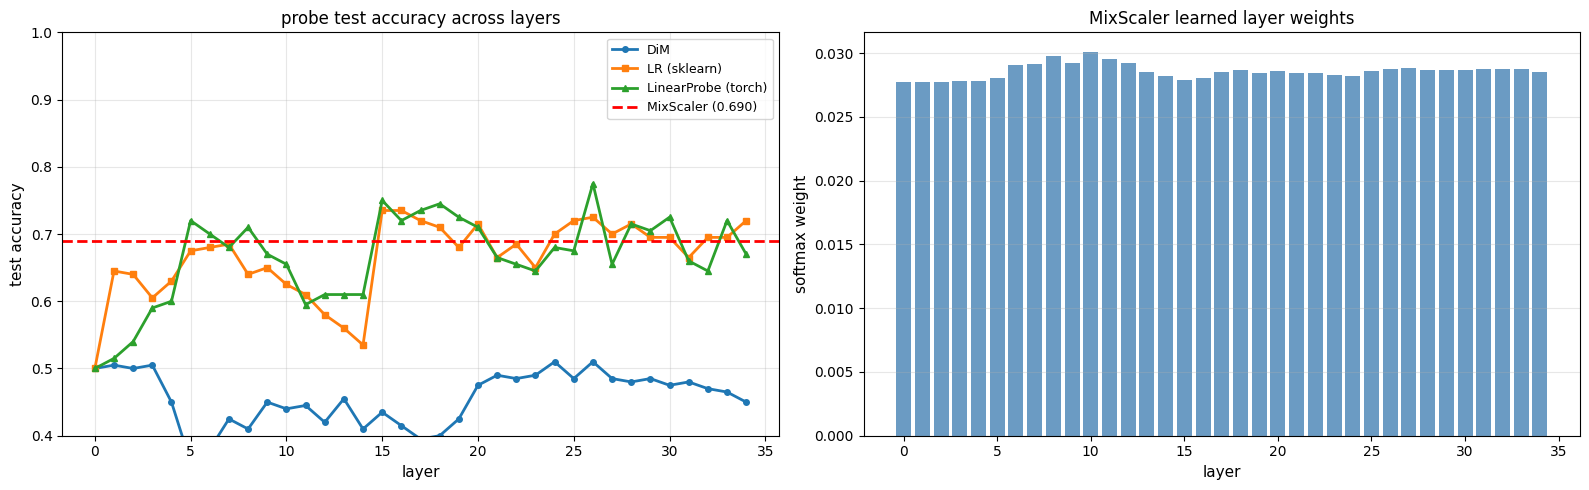

saved: plots/probe_comparison.png


In [17]:
Path("plots").mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(dim_results['layers'], dim_results['test_acc'],  'o-', label='DiM',              linewidth=2, markersize=4)
ax.plot(lr_results['layers'],  lr_results['test_acc'],   's-', label='LR (sklearn)',       linewidth=2, markersize=4)
ax.plot(lp_results['layers'],  lp_results['test_acc'],   '^-', label='LinearProbe (torch)', linewidth=2, markersize=4)
ax.axhline(mix_test_acc, color='red', linestyle='--', linewidth=2, label=f'MixScaler ({mix_test_acc:.3f})')
ax.set_xlabel('layer', fontsize=11)
ax.set_ylabel('test accuracy', fontsize=11)
ax.set_title('probe test accuracy across layers', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim([0.4, 1.0])

ax2 = axes[1]
ax2.bar(range(N_LAYERS), mix_layer_weights, color='steelblue', alpha=0.8)
ax2.set_xlabel('layer', fontsize=11)
ax2.set_ylabel('softmax weight', fontsize=11)
ax2.set_title('MixScaler learned layer weights', fontsize=12)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("saved: plots/probe_comparison.png")

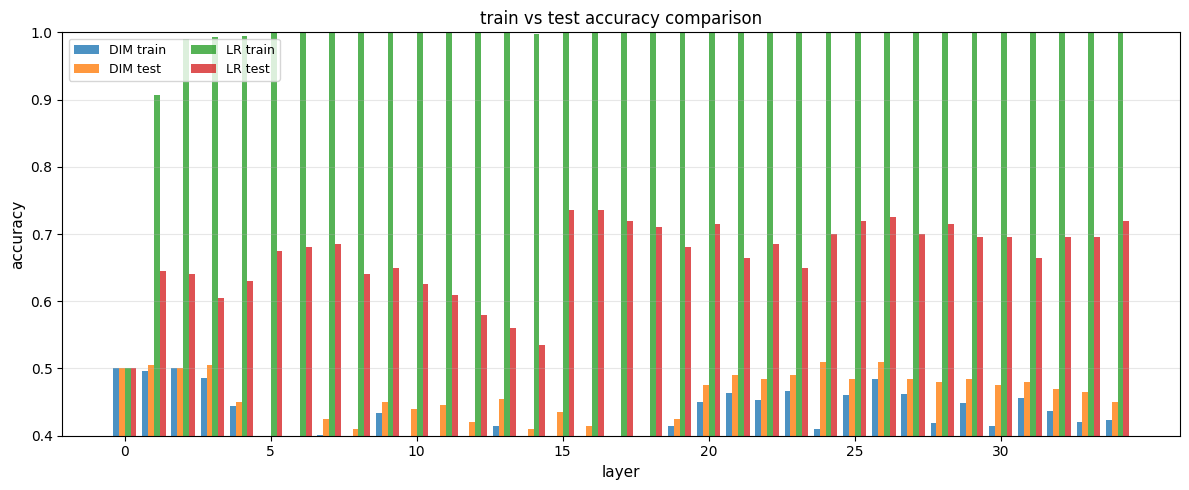

saved: plots/probe_train_vs_test.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(dim_results['layers']))
width = 0.2

ax.bar(x - 1.5*width, dim_results['train_acc'], width, label='DIM train', alpha=0.8)
ax.bar(x - 0.5*width, dim_results['test_acc'], width, label='DIM test', alpha=0.8)
ax.bar(x + 0.5*width, lr_results['train_acc'], width, label='LR train', alpha=0.8)
ax.bar(x + 1.5*width, lr_results['test_acc'], width, label='LR test', alpha=0.8)

ax.set_xlabel('layer', fontsize=11)
ax.set_ylabel('accuracy', fontsize=11)
ax.set_title('train vs test accuracy comparison', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.set_xticks(x[::5])
ax.set_xticklabels([str(i) for i in dim_results['layers'][::5]])
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0.4, 1.0])

plt.tight_layout()
plt.savefig('plots/probe_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("saved: plots/probe_train_vs_test.png")

In [19]:
dim_test_acc = np.array(dim_results['test_acc'])
lr_test_acc = np.array(lr_results['test_acc'])

best_dim_layer = np.argmax(dim_test_acc)
best_lr_layer = np.argmax(lr_test_acc)

print("="*50)
print("DIFFERENCE IN MEANS")
print("="*50)
print(f"best layer: {best_dim_layer} (acc={dim_test_acc[best_dim_layer]:.3f})")
print(f"avg: {dim_test_acc.mean():.3f} ± {dim_test_acc.std():.3f}")
print(f"range: {dim_test_acc.min():.3f} - {dim_test_acc.max():.3f}")

print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"best layer: {best_lr_layer} (acc={lr_test_acc[best_lr_layer]:.3f})")
print(f"avg: {lr_test_acc.mean():.3f} ± {lr_test_acc.std():.3f}")
print(f"range: {lr_test_acc.min():.3f} - {lr_test_acc.max():.3f}")

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
lr_better = np.sum(lr_test_acc > dim_test_acc)
print(f"LR better: {lr_better}/{N_LAYERS} layers")
print(f"avg gap: {(lr_test_acc - dim_test_acc).mean():.4f}")
print(f"max gap: {(lr_test_acc - dim_test_acc).max():.4f}")

DIFFERENCE IN MEANS
best layer: 24 (acc=0.510)
avg: 0.456 ± 0.039
range: 0.360 - 0.510

LOGISTIC REGRESSION
best layer: 15 (acc=0.735)
avg: 0.665 ± 0.056
range: 0.500 - 0.735

COMPARISON
LR better: 34/35 layers
avg gap: 0.2091
max gap: 0.3250
